# M146 Final Project - Hints / Starter Notebook

This notebook is meant to make the project runnable in Google Colab. Most helper code is provided. Your job is to run the experiments, make a few intuitive choices, and explain what you observe.

The main Part B path is: base model -> LoRA 1k -> LoRA 2k -> 3-shot prompting. The prompt playground at the end is bonus.


In [4]:

# Colab setup: run this once in a fresh runtime if imports fail.
%pip install -q -U datasets transformers accelerate sentence-transformers scikit-learn matplotlib peft trl bitsandbytes

In [5]:

import os
import re
import gc
import json
import math
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = Path("m146_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Device:", DEVICE)


Device: cuda


In [6]:
def clear_memory(*names):
    """Delete large variables by name and clear Python/CUDA memory."""
    for name in names:
        if name in globals():
            del globals()[name]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


## Part A: PAWS Sentence-Pair Classification


In [ ]:
# changed this link so that I can load the dataset in VS code
paws = load_dataset("google-research-datasets/paws", "labeled_final")

# use the following if you're just using Google Colab
#paws = load_dataset("paws", "labeled_final")

paws


README.md:   0%|          | 0.00/9.79k [00:00<?, ?B/s]

labeled_final/train-00000-of-00001.parqu(…):   0%|          | 0.00/8.43M [00:00<?, ?B/s]

labeled_final/test-00000-of-00001.parque(…):   0%|          | 0.00/1.24M [00:00<?, ?B/s]

labeled_final/validation-00000-of-00001.(…):   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/49401 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 49401
    })
    test: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 8000
    })
})

### A.1 Data Inspection and Lexical Overlap

Report split sizes and label balance, compute a lexical overlap score (e.g., Jaccard) for the test split, and plot overlap histograms by label. Write the supporting code yourself.

train split: 49401 examples
  Label 0: 27572 examples (55.81%)
  Label 1: 21829 examples (44.19%)
test split: 8000 examples
  Label 0: 4464 examples (55.80%)
  Label 1: 3536 examples (44.20%)
validation split: 8000 examples
  Label 0: 4461 examples (55.76%)
  Label 1: 3539 examples (44.24%)
Average Jaccard similarity for test split: 0.89


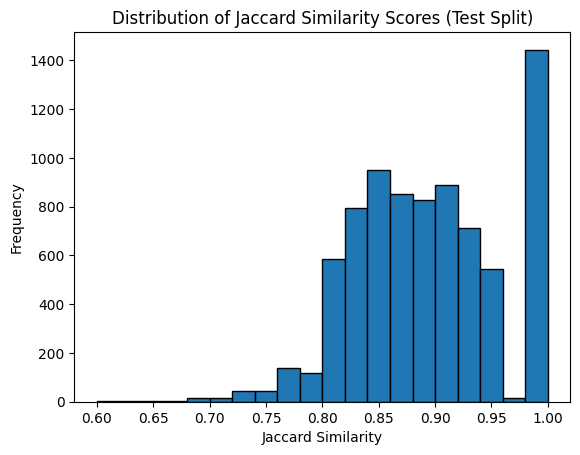

In [ ]:
# report split sizes and label balance
for split_name, dataset in paws.items():
    labels = dataset["label"]
    label_counts = Counter(labels)
    total = len(labels)
    print(f"{split_name} split: {total} examples")
    for label, count in label_counts.items():
        percentage = (count / total) * 100
        print(f"  Label {label}: {count} examples ({percentage:.2f}%)")

# compute lexical overlap score (Jaccard similarity) for the test split
def jaccard_similarity(str1, str2):
    set1 = set(re.findall(r"\w+", str1.lower()))
    set2 = set(re.findall(r"\w+", str2.lower()))
    intersection = set1.intersection(set2)
    union = set1.union(set2)

    # uses the ratio of the intersection size to the union size as the similarity score
    return len(intersection) / len(union) if union else 0.0

test_dataset = paws["test"]
sentences1 = test_dataset["sentence1"]
sentences2 = test_dataset["sentence2"]

jaccard_scores = [jaccard_similarity(s1, s2) for s1, s2 in zip(sentences1, sentences2)]
print(f"Average Jaccard similarity for test split: {sum(jaccard_scores) / len(jaccard_scores):.2f}")

# plots overlap histogram for test split
plt.hist(jaccard_scores, bins=20, edgecolor="black")
plt.title("Distribution of Jaccard Similarity Scores (Test Split)")
plt.xlabel("Jaccard Similarity")
plt.ylabel("Frequency")
plt.show()

Before training A.2 models, write your hypothesis: which should work better on PAWS, bi-encoder or cross-encoder, and why?


In [13]:
# our hypothesis is in the markdown cell below

(Hypothesis here)

### A.2 Encoder Models

Run the cells and report accuracy, F1, confusion matrices, disagreements, and the accuracy-efficiency tradeoff.


In [ ]:
from sentence_transformers import SentenceTransformer

BI_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
bi_encoder = SentenceTransformer(BI_MODEL, device=str(DEVICE))


def encode_sentences(texts, batch_size=128):
    return bi_encoder.encode(
        list(texts),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )

# Use encode_sentences() to get u = enc(sentence1) and v = enc(sentence2).
# Decide your own pair-feature construction and train a classifier on the train split,
# tuning C on the validation split. Report your feature choice in the report.


Use the bi-encoder helper functions above to build sentence-pair features, train a simple classifier, and report validation/test metrics. Do not forget the confusion matrix.

In [ ]:

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

CROSS_MODEL = "distilbert-base-uncased"
MAX_LEN = 128
cross_tokenizer = AutoTokenizer.from_pretrained(CROSS_MODEL)


def tokenize_pairs(batch):
    return cross_tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
    )


def binary_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds), "f1": f1_score(labels, preds)}


def training_args(output_dir, learning_rate):
    kwargs = dict(
        output_dir=output_dir,
        learning_rate=learning_rate,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        num_train_epochs=1,
        save_strategy="no",
        report_to="none",
        fp16=torch.cuda.is_available(),
        logging_steps=100,
    )
    try:
        return TrainingArguments(eval_strategy="epoch", **kwargs)
    except TypeError:
        return TrainingArguments(evaluation_strategy="epoch", **kwargs)


def train_cross_encoder(tokenized_ds, lr=2e-5):
    model = AutoModelForSequenceClassification.from_pretrained(CROSS_MODEL, num_labels=2)
    args = training_args(f"m146_outputs/cross_encoder_lr_{lr}", lr)
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["validation"],
        tokenizer=cross_tokenizer,
        compute_metrics=binary_metrics,
    )
    trainer.train()
    return trainer, trainer.evaluate()


Use the cross-encoder helper functions above to tokenize PAWS sentence pairs and fine-tune a small classifier. Try the learning rates suggested in the PDF if compute allows.

After both encoder models are evaluated, inspect test examples where their predictions disagree and describe the patterns you see.

> **Memory tip:** Before loading the instruction model for A.3, free GPU memory by running `clear_memory("bi_encoder", "trainer")` (or whatever names you used).

### A.3 Prompt-Based PAWS Classification

This cell gives model-loading and evaluation utilities. Write the actual PAWS prompt yourself in `PAWS_PROMPT_TEMPLATE`. Keep the output labels parseable as `paraphrase` and `not_paraphrase`.


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

INSTRUCT_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"

# Write your PAWS classification prompt here.
# IMPORTANT: Use {sentence1} and {sentence2} where the two sentences should be inserted in the prompt.
PAWS_PROMPT_TEMPLATE = """
""".strip()


def load_instruct_model(model_name=INSTRUCT_MODEL):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
    )
    model.eval()
    return model, tokenizer


def chat_text(tokenizer, messages):
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def make_paws_prompt(sentence1, sentence2, prompt_template=PAWS_PROMPT_TEMPLATE):
    return prompt_template.format(sentence1=sentence1, sentence2=sentence2)


def parse_paws_output(text):
    cleaned = text.strip().lower().replace("-", "_").replace(" ", "_")
    if "not_paraphrase" in cleaned:
        return 0
    if re.search(r"\bparaphrase\b", cleaned):
        return 1
    return -1


def balanced_subset(split, n_per_class=100, seed=SEED):
    rng = np.random.default_rng(seed)
    labels = np.array(split["label"])
    indices = []
    for label in [0, 1]:
        candidates = np.flatnonzero(labels == label)
        indices.extend(rng.choice(candidates, size=n_per_class, replace=False).tolist())
    rng.shuffle(indices)
    return split.select(indices), indices


def generate_texts(model, tokenizer, prompts, max_new_tokens=8, batch_size=8):
    outputs = []
    for start in range(0, len(prompts), batch_size):
        batch = prompts[start:start + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(model.device)
        prompt_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            generated = model.generate(**inputs, do_sample=False, max_new_tokens=max_new_tokens)
        for i in range(len(batch)):
            outputs.append(tokenizer.decode(generated[i][prompt_len:], skip_special_tokens=True).strip())
    return outputs


def evaluate_prompted_paws(model, tokenizer, split, prompt_template=PAWS_PROMPT_TEMPLATE, few_shot_examples=None, batch_size=8):
    prompts = []
    for ex in split:
        messages = []
        if few_shot_examples:
            for fs in few_shot_examples:
                messages.append({"role": "user", "content": make_paws_prompt(fs["sentence1"], fs["sentence2"], prompt_template)})
                messages.append({"role": "assistant", "content": "paraphrase" if fs["label"] == 1 else "not_paraphrase"})
        messages.append({"role": "user", "content": make_paws_prompt(ex["sentence1"], ex["sentence2"], prompt_template)})
        prompts.append(chat_text(tokenizer, messages))
    raw = generate_texts(model, tokenizer, prompts, batch_size=batch_size)
    pred = np.array([parse_paws_output(x) for x in raw])
    y = np.array(split["label"])
    valid = pred != -1
    return {
        "accuracy_invalid_wrong": float((pred == y).mean()),
        "coverage": float(valid.mean()),
        "accuracy_valid_only": accuracy_score(y[valid], pred[valid]) if valid.any() else np.nan,
        "confusion_matrix": confusion_matrix(y[valid], pred[valid], labels=[0, 1]) if valid.any() else None,
        "pred": pred,
        "raw": raw,
    }


For A.3, load the instruction model, create the fixed balanced PAWS test subset, write your own prompt, and evaluate the prompted classifier.

For the few-shot PAWS prompt, choose 4-6 labeled examples from the training split only. Then compare zero-shot, few-shot, and one alternate prompt wording.

> **Memory tip:** Before loading the GSM8K math model, free GPU memory by running `clear_memory("instruct_model", "instruct_tokenizer")` (or whatever names you used).

## Part B: GSM8K Reasoning

The prompt below is intentionally minimal. You can add your own instructions above the final-answer rule.


In [ ]:
# You may add creative instructions above the final-answer rule.
# If you do nothing, this minimal prompt still runs.
# Keep the final line parseable, or the evaluator may mark correct reasoning as wrong. 
# Do not remove the boxed answer rule. Please edit the first line of the prompt and add your instructions (however long you want).
SYSTEM_PROMPT = """
Your task is to solve the math problem.

Final answer rule:
The last line of your response must be exactly:
\\boxed{ANSWER}
""".strip()


In [ ]:

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, PeftModel, TaskType
from trl import SFTTrainer, SFTConfig

MATH_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
N_EVAL = 100

gsm8k = load_dataset("openai/gsm8k", "main")
gsm8k_test_100 = gsm8k["test"].select(range(N_EVAL))

def extract_boxed(text):
    idx = text.rfind("\\boxed{")
    if idx == -1:
        return None
    start = idx + len("\\boxed{")
    depth = 1
    pos = start
    while pos < len(text) and depth > 0:
        if text[pos] == "{":
            depth += 1
        elif text[pos] == "}":
            depth -= 1
        pos += 1
    if depth != 0:
        return None
    return text[start:pos - 1]


def extract_gt(raw_answer):
    match = re.search(r"####\s*(.+)", raw_answer)
    return match.group(1).strip().replace(",", "") if match else raw_answer.strip()


def extract_model_answer(text):
    boxed = extract_boxed(text)
    if boxed is not None:
        return boxed.strip()
    nums = re.findall(r"-?\d+(?:\.\d+)?", text)
    return nums[-1] if nums else ""


def normalize_answer(ans):
    s = str(ans).strip().replace(",", "").replace("$", "").replace("%", "").replace(" ", "")
    s = re.sub(r"\\text\{([^}]*)\}", r"\1", s)
    s = re.sub(r"\\(left|right|displaystyle)", "", s)
    s = re.sub(r"\\d?frac\{([^}]+)\}\{([^}]+)\}", r"\1/\2", s)
    try:
        v = float(s)
        if math.isfinite(v):
            return str(int(v)) if v == int(v) else str(v)
    except (ValueError, OverflowError):
        pass
    if "/" in s and s.count("/") == 1:
        try:
            a, b = s.split("/")
            return f"{float(a) / float(b):.10g}"
        except (ValueError, ZeroDivisionError):
            pass
    return s


def answers_match(pred, gt):
    p, g = normalize_answer(pred), normalize_answer(gt)
    if p == g:
        return True
    try:
        return abs(float(p) - float(g)) < 1e-6
    except (ValueError, TypeError):
        return False


def load_math_model(model_name=MATH_MODEL, lora_path=None):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
        attn_implementation="eager",
    )
    if lora_path:
        model = PeftModel.from_pretrained(model, lora_path)
    model.eval()
    return model, tokenizer


def make_gsm_prompts(tokenizer, questions, system_prompt=SYSTEM_PROMPT, few_shot_messages=None):
    prompts = []
    for q in questions:
        messages = [{"role": "system", "content": system_prompt}]
        if few_shot_messages:
            messages.extend(few_shot_messages)
        messages.append({"role": "user", "content": q})
        prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))
    return prompts


def generate_math(model, tokenizer, questions, system_prompt=SYSTEM_PROMPT, few_shot_messages=None, batch_size=16, max_new_tokens=512):
    responses = []
    for start in range(0, len(questions), batch_size):
        batch_questions = questions[start:start + batch_size]
        prompts = make_gsm_prompts(tokenizer, batch_questions, system_prompt=system_prompt, few_shot_messages=few_shot_messages)
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(model.device)
        prompt_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            out = model.generate(**inputs, do_sample=False, max_new_tokens=max_new_tokens)
        for i in range(len(batch_questions)):
            responses.append(tokenizer.decode(out[i][prompt_len:], skip_special_tokens=True).strip())
    return responses


def evaluate_gsm8k(model, tokenizer, split, num_samples=100, system_prompt=SYSTEM_PROMPT, few_shot_messages=None, batch_size=16, output_name=None):
    n = min(num_samples, len(split))
    records = []
    correct = 0
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        questions = [split[i]["question"] for i in range(start, end)]
        gts = [extract_gt(split[i]["answer"]) for i in range(start, end)]
        responses = generate_math(model, tokenizer, questions, system_prompt=system_prompt, few_shot_messages=few_shot_messages, batch_size=batch_size)
        for offset, (q, gt, resp) in enumerate(zip(questions, gts, responses)):
            pred = extract_model_answer(resp)
            ok = answers_match(pred, gt)
            correct += int(ok)
            records.append({
                "index": start + offset,
                "question": q,
                "ground_truth": gt,
                "model_response": resp,
                "extracted_answer": pred,
                "correct": ok,
            })
    result = {"accuracy": correct / n, "correct": correct, "total": n, "records": records}
    if output_name:
        path = OUTPUT_DIR / output_name
        path.write_text(json.dumps(result, indent=2))
    return result


### B.1-B.2 Base Model Evaluation


For B.1, load the base Qwen2.5-1.5B-Instruct model and evaluate it on the fixed 100 GSM8K test questions.

### B.3-B.7 LoRA Fine-Tuning

The training utilities are provided below. Run the 1k and 2k experiments yourself and record the results in your report.


In [ ]:

LORA_DEFAULTS = {
    "rank": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"],
    "learning_rate": 2e-4,
    "epochs": 1,
    "batch_size": 8,
    "grad_accum": 4,
    "max_seq_len": 1024,
}


def build_lora_config():
    return LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=LORA_DEFAULTS["rank"],
        lora_alpha=LORA_DEFAULTS["lora_alpha"],
        lora_dropout=LORA_DEFAULTS["lora_dropout"],
        target_modules=LORA_DEFAULTS["target_modules"],
        bias="none",
    )


def format_gsm8k_train_example(example):
    reasoning = example["answer"].split("####")[0].strip()
    final = extract_gt(example["answer"])
    assistant = f"{reasoning}\n\n\\boxed{{{final}}}"
    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": example["question"]},
            {"role": "assistant", "content": assistant},
        ]
    }


def train_lora_sft(num_samples, output_dir, model_name=MATH_MODEL):
    output_dir = Path(output_dir)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "right"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
        attn_implementation="eager",
    )
    model = get_peft_model(model, build_lora_config())
    model.print_trainable_parameters()

    train_data = gsm8k["train"].select(range(min(num_samples, len(gsm8k["train"]))))
    train_data = train_data.map(format_gsm8k_train_example, remove_columns=train_data.column_names)

    args = SFTConfig(
        output_dir=str(output_dir),
        num_train_epochs=LORA_DEFAULTS["epochs"],
        per_device_train_batch_size=LORA_DEFAULTS["batch_size"],
        gradient_accumulation_steps=LORA_DEFAULTS["grad_accum"],
        learning_rate=LORA_DEFAULTS["learning_rate"],
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        bf16=torch.cuda.is_available(),
        logging_steps=10,
        save_strategy="epoch",
        save_total_limit=1,
        report_to="none",
        max_length=LORA_DEFAULTS["max_seq_len"],
        completion_only_loss=True,
    )
    trainer = SFTTrainer(model=model, args=args, train_dataset=train_data, processing_class=tokenizer)
    trainer.train()

    adapter_path = output_dir / "final_adapter"
    model.save_pretrained(adapter_path)
    tokenizer.save_pretrained(adapter_path)
    return str(adapter_path)


> **Memory tip:** Before LoRA training (and between LoRA runs), free GPU memory by running `clear_memory("math_model", "math_tokenizer")` so the base model isn't still resident.

For B.5, train the provided LoRA template on 1,000 GSM8K training examples, then evaluate on the same 100-question test subset.

Write your scaling hypothesis before running 2k. Do you expect a meaningful improvement over 1k? Why?


For B.7, train the provided LoRA template on 2,000 examples and evaluate on the same 100-question test subset.

Make the B.7 accuracy-vs-training-size plot yourself using your results for 0, 1000, and 2000 training examples.


### B.10-B.11 Few-Shot Prompting


In [ ]:

def few_shot_messages_from_train(train_split, indices=(0, 1, 2)):
    messages = []
    for idx in indices:
        ex = train_split[int(idx)]
        reasoning = ex["answer"].split("####")[0].strip()
        final = extract_gt(ex["answer"])
        messages.append({"role": "user", "content": ex["question"]})
        messages.append({"role": "assistant", "content": f"{reasoning}\n\n\\boxed{{{final}}}"})
    return messages

For B.10, build one fixed set of 3 GSM8K training examples and use it for both the base model and the 2k LoRA model. Then compare zero-shot and 3-shot accuracy.

### Bonus: Prompt Playground

For the bonus, start from the original prompt, then write your own prompt variants. You do not need to stop at three trials if you want to keep experimenting.


In [ ]:
# Keep PROMPT_0 as the old prompt. Fill in PROMPT_1, PROMPT_2, PROMPT_3 yourself.
PROMPT_0 = SYSTEM_PROMPT

PROMPT_1 = """
""".strip()

PROMPT_2 = """
""".strip()

PROMPT_3 = """
""".strip()


def evaluate_one_prompt(model, tokenizer, prompt, name="prompt", n=50):
    result = evaluate_gsm8k(
        model,
        tokenizer,
        gsm8k["test"].select(range(n)),
        num_samples=n,
        system_prompt=prompt,
        batch_size=16,
    )
    return {"prompt_name": name, "accuracy": result["accuracy"], "correct": result["correct"], "total": result["total"]}, result

# Baseline bonus run using the old prompt. After this, run your own prompt variants.
if "math_model" not in globals() or "math_tokenizer" not in globals():
    math_model, math_tokenizer = load_math_model()

baseline_row, baseline_result = evaluate_one_prompt(math_model, math_tokenizer, PROMPT_0, name="old_prompt")
baseline_row
